In [184]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px 

import warnings 
warnings.filterwarnings("ignore")

In [185]:
df = pd.read_csv(r"C:\Users\Sh2\Downloads\HR_Data_MNC_Data Science Lovers.csv")
df

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


In [186]:
df.drop(columns=['Unnamed: 0'], inplace= True)
df

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 11 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   Employee_ID         object
 1   Full_Name           object
 2   Department          object
 3   Job_Title           object
 4   Hire_Date           object
 5   Location            object
 6   Performance_Rating  int64 
 7   Experience_Years    int64 
 8   Status              object
 9   Work_Mode           object
 10  Salary_INR          int64 
dtypes: int64(3), object(8)
memory usage: 167.8+ MB


In [188]:
df.Hire_Date = pd.to_datetime(df["Hire_Date"], yearfirst= True, errors="coerce" )

In [189]:
df.duplicated().sum()

0

In [190]:
df.Employee_ID.duplicated().sum()

0

In [191]:
df.isna().sum()

Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

In [192]:
df.describe()

,Hire_Date,Performance_Rating,Experience_Years,Salary_INR
count,2000000,2.000000e+06,2.000000e+06,2.000000e+06
mean,2020-02-11 07:02:40.689599488,3.000148e+00,5.010287e+00,8.968878e+05
min,2010-08-14 00:00:00,1.000000e+00,0.000000e+00,3.000000e+05
25%,2017-06-27 00:00:00,2.000000e+00,2.000000e+00,6.163460e+05
50%,2020-08-12 00:00:00,3.000000e+00,5.000000e+00,8.110265e+05
75%,2023-02-09 00:00:00,4.000000e+00,8.000000e+00,1.073745e+06
max,2025-08-13 00:00:00,5.000000e+00,1.500000e+01,2.999976e+06
std,NaN,1.413973e+00,3.608823e+00,4.026103e+05


<Axes: xlabel='Salary_INR', ylabel='Count'>

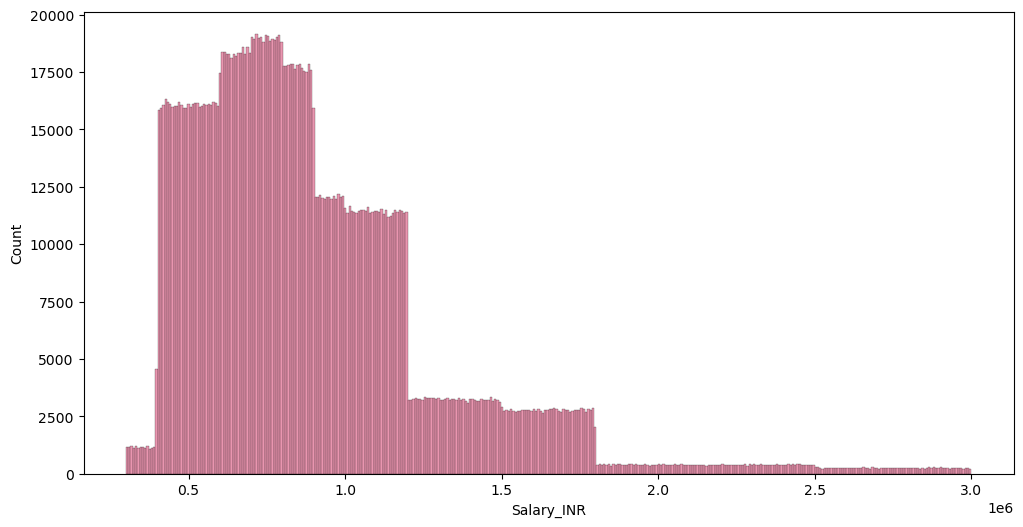

In [193]:
plt.figure(figsize=(12,6))
sns.histplot(x=df["Salary_INR"],color='#e27396')

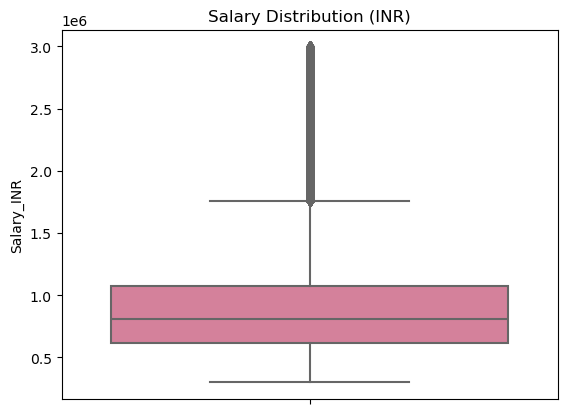

In [194]:
sns.boxplot(y=df["Salary_INR"], color='#e27396')
plt.title("Salary Distribution (INR)")
plt.show()

In [195]:
#salary_outlier
Q3 = 1.073745e+06
Q1 = 6.163460e+05
IQR = Q3 - Q1 
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)

lower_bound = Q1 - 1.5 * IQR 
print(lower_bound)

1759843.5
-69752.5


In [196]:
salary_outlier = df[df.Salary_INR > 1759843.5]
salary_outlier

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
24,EMP0000025,Amanda Miller,IT,IT Manager,2021-07-31,"Tammyview, Barbados",2,4,Active,Remote,2153098
32,EMP0000033,Cristian Thomas,IT,IT Manager,2021-02-14,"North Markbury, San Marino",3,4,Active,Remote,2408177
34,EMP0000035,Kathleen Shields,IT,IT Manager,2023-07-26,"North Brianmouth, Zambia",1,2,Retired,On-site,2615626
103,EMP0000104,Tamara Wilson,Finance,Finance Manager,2023-01-10,"South Stevenmouth, South Georgia and the South...",2,2,Resigned,On-site,2118072
143,EMP0000144,Jane Mcintyre,IT,IT Manager,2024-09-16,"Housemouth, Guam",4,0,Active,On-site,2194883
...,...,...,...,...,...,...,...,...,...,...,...
1999878,EMP1999879,Kyle Harrington,IT,Software Engineer,2017-03-26,"Joshuaton, Pakistan",5,8,Resigned,On-site,1787416
1999891,EMP1999892,Amy Larson,IT,IT Manager,2025-01-30,"Scottbury, Panama",5,0,Active,Remote,2280784
1999908,EMP1999909,Adam Parker,IT,IT Manager,2023-01-10,"Keithland, Andorra",1,2,Active,Remote,2797393
1999941,EMP1999942,Lisa Sanders,Finance,Finance Manager,2016-03-14,"Emmaberg, Argentina",2,9,Active,On-site,2010855


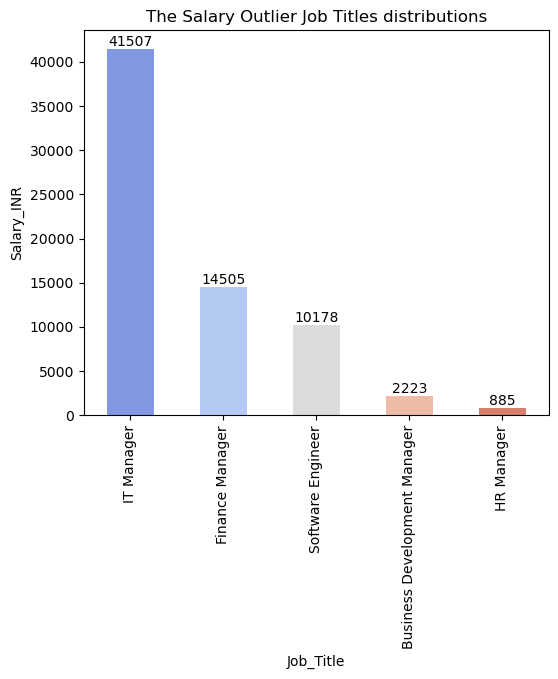

In [197]:
outlier_title = salary_outlier.groupby("Job_Title")["Salary_INR"].count().reset_index().sort_values(by="Salary_INR", ascending=False)
outlier_title

plt.figure(figsize=(6,5))
ax = sns.barplot(outlier_title, x = "Job_Title", y = "Salary_INR", palette="coolwarm", width=0.5)
for i in ax.containers: 
    ax.bar_label(i)

plt.title("The Salary Outlier Job Titles distributions")

plt.xticks(rotation = 90)
plt.show()

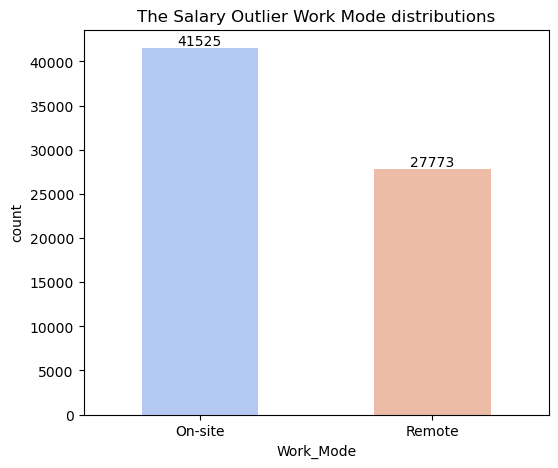

In [198]:
outlier_work_mode = salary_outlier.Work_Mode.value_counts().reset_index()
outlier_work_mode

plt.figure(figsize=(6,5))
ax = sns.barplot(outlier_work_mode, x = "Work_Mode", y = "count", palette="coolwarm", width=0.5)
for i in ax.containers: 
    ax.bar_label(i)

plt.title("The Salary Outlier Work Mode distributions")

plt.show()

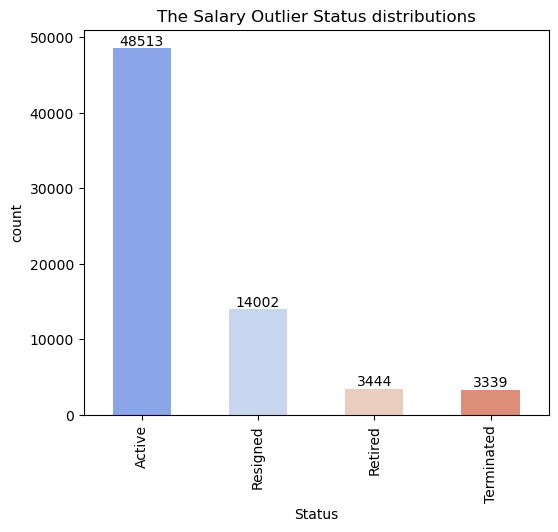

In [199]:
outlier_Status = salary_outlier.Status.value_counts().reset_index()
outlier_Status

plt.figure(figsize=(6,5))
ax = sns.barplot(outlier_Status, x = "Status", y = "count", palette="coolwarm", width=0.5)
for i in ax.containers: 
    ax.bar_label(i)
    
plt.title("The Salary Outlier Status distributions")

plt.xticks(rotation = 90)
plt.show()

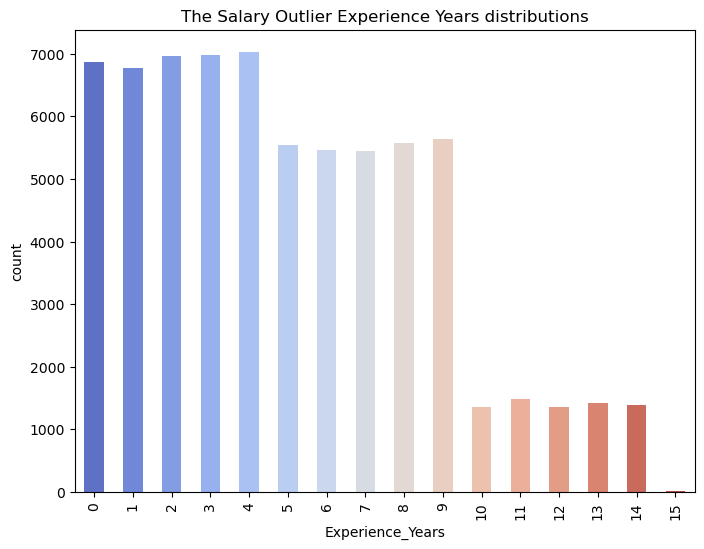

In [200]:
outlier_Status = salary_outlier["Experience_Years"].value_counts().reset_index()
outlier_Status

plt.figure(figsize=(8,6))
ax = sns.barplot(outlier_Status, x = "Experience_Years", y = "count", palette="coolwarm", width=0.5)
#for i in ax.containers: 
#    ax.bar_label(i)
    
plt.title("The Salary Outlier Experience Years distributions")

plt.xticks(rotation = 90)
plt.show()

In [201]:
df["Salary_rating"] = df.Salary_INR.apply(lambda x : "High" if x > 1759843.5 else "Normal")

In [202]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_rating
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,Normal
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,Normal
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,Normal
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,Normal
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,Normal


In [203]:
df.describe(include= "O")

,Employee_ID,Full_Name,Department,Job_Title,Location,Status,Work_Mode,Salary_rating
count,2000000,2000000,2000000,2000000,2000000,2000000,2000000,2000000
unique,2000000,467487,7,29,1593497,4,2,2
top,EMP0000001,Michael Smith,IT,Software Engineer,"Lake Michael, Congo",Active,On-site,Normal
freq,1,1014,601042,300358,20,1401558,1199109,1930702


In [204]:
df.Status.value_counts()

Status
Active        1401558
Resigned       398660
Retired         99912
Terminated      99870
Name: count, dtype: int64

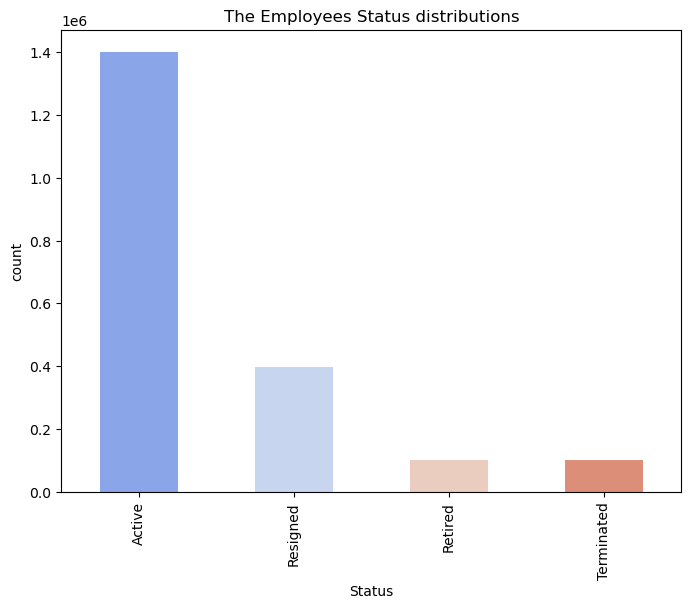

In [205]:
status = df.Status.value_counts().reset_index()
status

plt.figure(figsize=(8,6))
ax = sns.barplot(status, x = "Status", y = "count", palette="coolwarm", width=0.5)
#for i in ax.containers: 
#    ax.bar_label(i)
    
plt.title("The Employees Status distributions")

plt.xticks(rotation = 90)
plt.show()

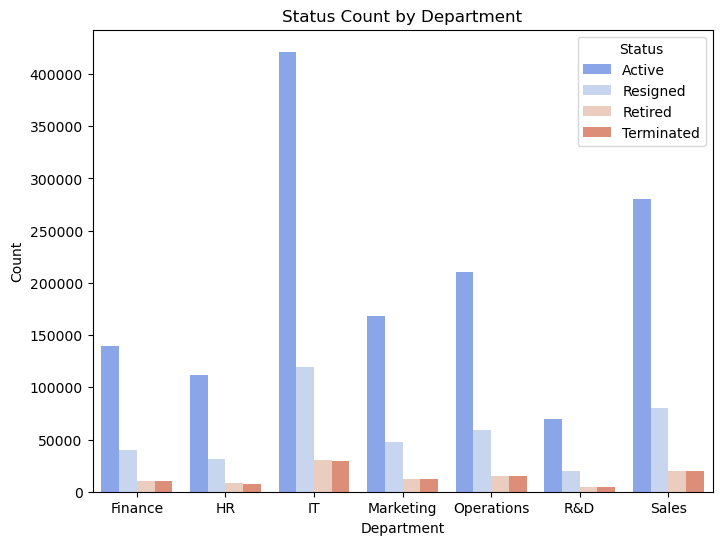

In [206]:
status = df.pivot_table(index="Status", columns="Department", aggfunc="size").reset_index()
status

status_melted = status.melt(id_vars="Status", var_name="Department", value_name="Count")
status_melted

plt.figure(figsize=(8,6))
sns.barplot(data=status_melted, x="Department", y="Count", hue="Status", palette="coolwarm")
plt.title("Status Count by Department")
plt.show()


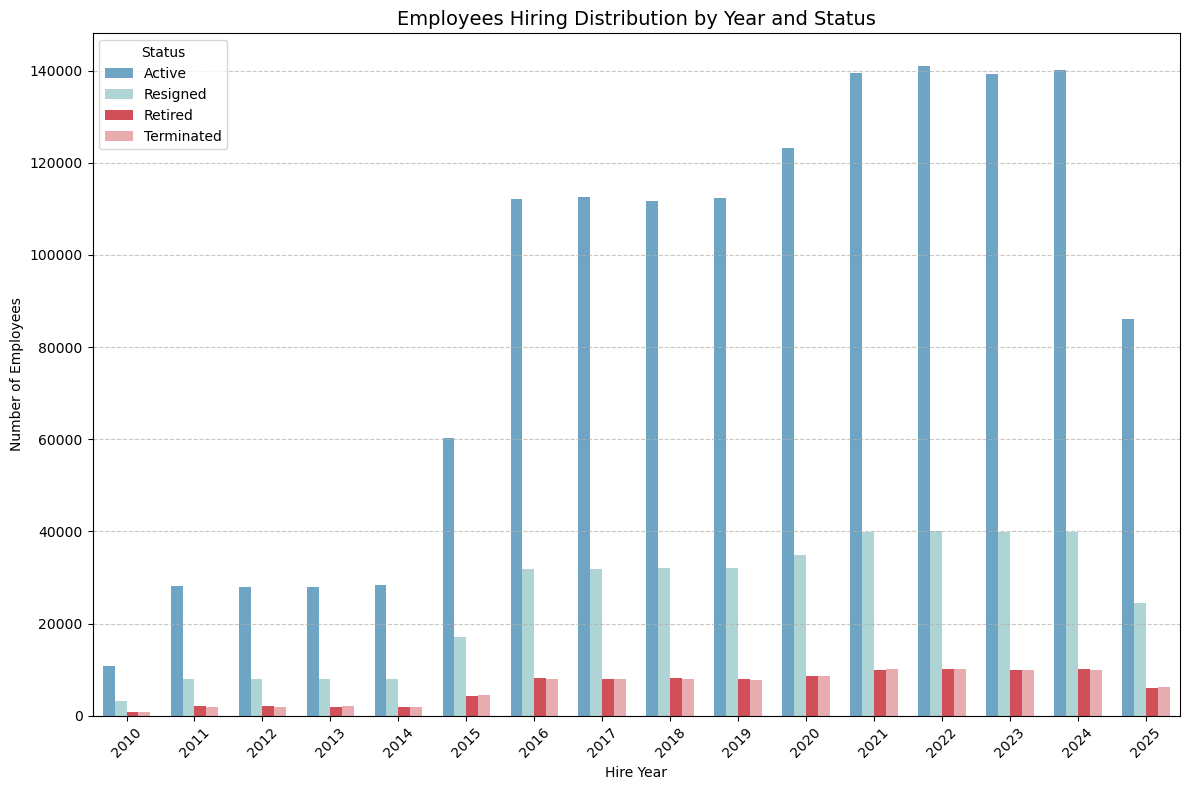

In [207]:
df["Hire_Year"] = df["Hire_Date"].dt.year
filtered_df = df[df["Status"].isin(["Active", "Resigned", "Retired", "Terminated"])]

years_of_hiring = (
    filtered_df.groupby(["Hire_Year", "Status"])
    .size()
    .reset_index(name="Count")
    .sort_values("Hire_Year")
)

plt.figure(figsize=(12,8))
ax = sns.barplot(
    data=years_of_hiring,
    x="Hire_Year",
    y="Count",
    hue="Status",
    palette=["#5FA8D3", "#A8DADC", "#E63946", "#F1A1A8"],
    width=0.7
)

plt.title("Employees Hiring Distribution by Year and Status", fontsize=14)
plt.xlabel("Hire Year")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.legend(title="Status")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

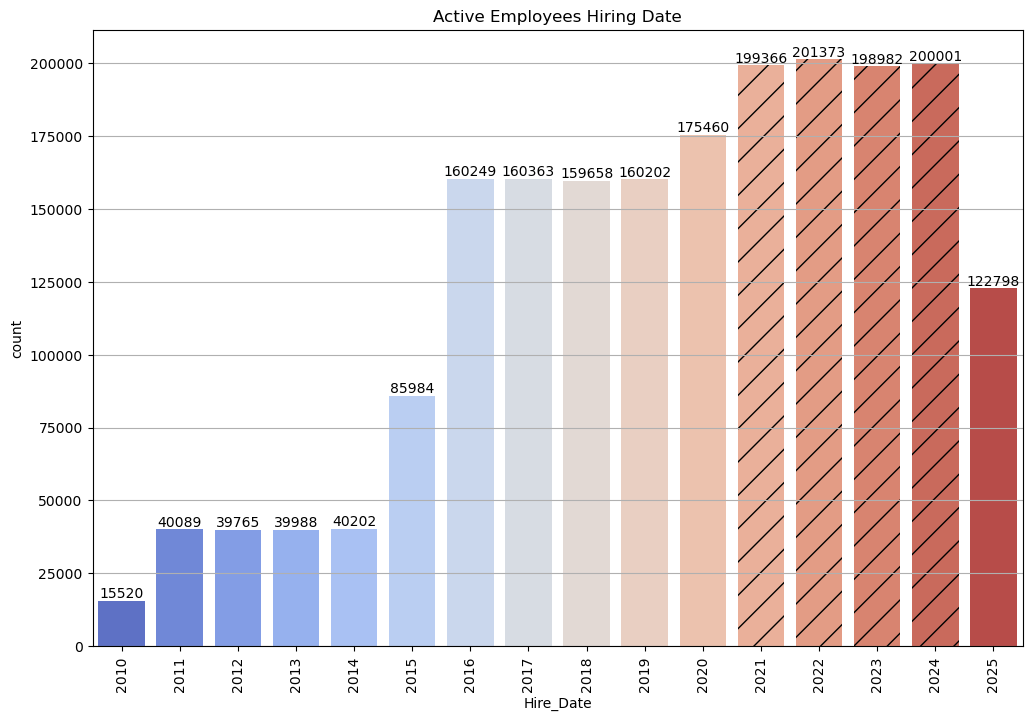

In [208]:
years_of_hiring = df[(df.Status == "Active") | (df.Status == "Resigned") | (df.Status == "Retired") | (df.Status == "Terminated")]["Hire_Date"].dt.year.value_counts().reset_index()
years_of_hiring

plt.figure(figsize=(12,8))
ax = sns.barplot(years_of_hiring, x="Hire_Date", y="count", palette="coolwarm", width=0.8)

bars = ax.patches
bars[-2].set_hatch("/")
bars[-3].set_hatch("/")
bars[-4].set_hatch("/")
bars[-5].set_hatch("/")

for i in ax.containers: 
    ax.bar_label(i)

plt.title("Active Employees Hiring Date")
plt.xticks(rotation = 90)

plt.grid(axis="y")
plt.show()

In [209]:
filtered_df = df[(df["Hire_Date"].dt.year == 2021) |(df["Hire_Date"].dt.year == 2022) |(df["Hire_Date"].dt.year == 2023) |(df["Hire_Date"].dt.year == 2024)]
filtered_df

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_rating,Hire_Year
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,Normal,2023
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,Normal,2023
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,Normal,2024
5,EMP0000006,Jason Gardner,Operations,Logistics Coordinator,2021-02-23,"Zimmermanstad, Bulgaria",5,4,Active,On-site,641393,Normal,2021
11,EMP0000012,Kevin Lowe,Sales,Account Manager,2024-07-02,"East Kent, Qatar",3,1,Resigned,On-site,1111759,Normal,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999988,EMP1999989,Kayla Ellis,Operations,Supply Chain Manager,2024-11-22,"Port Christineberg, Croatia",5,0,Active,On-site,482185,Normal,2024
1999992,EMP1999993,Phillip Small,IT,Data Analyst,2021-10-17,"Gonzalezstad, Korea",1,3,Active,On-site,957820,Normal,2021
1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109,Normal,2021
1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085,Normal,2024


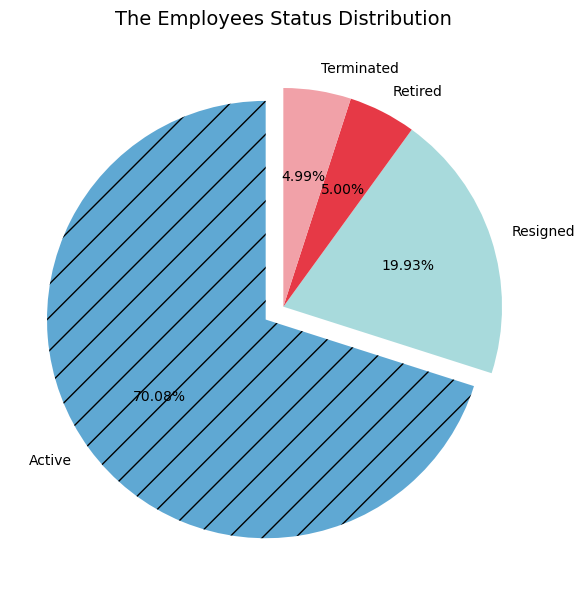

In [210]:
status = df["Status"].value_counts().reset_index() 
status

plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(
    status["count"],
    autopct="%1.2f%%",
    labels=status["Status"],
    colors=["#5FA8D3", "#A8DADC", "#E63946", "#F1A1A8"],
    explode=[0.1, 0, 0, 0],
    startangle=90
)

wedges[0].set_hatch("/")

plt.title("The Employees Status Distribution", fontsize=14)
plt.tight_layout()
plt.show()

In [211]:
df[df.Status == "Active"]["Performance_Rating"].mean()

3.001283571568212

In [212]:
df[df.Status == "Active"]["Experience_Years"].value_counts()

Experience_Years
3     140315
4     140201
2     140069
1     139695
0     138964
6     112549
8     112464
5     112266
9     112200
7     111281
10     28785
13     28218
11     28186
14     28113
12     27836
15       416
Name: count, dtype: int64

In [213]:
df[df.Status == "Active"]["Work_Mode"].value_counts()

Work_Mode
On-site    840332
Remote     561226
Name: count, dtype: int64

In [214]:
df[df.Status == "Active"]["Salary_INR"].mean()

896893.2525132746

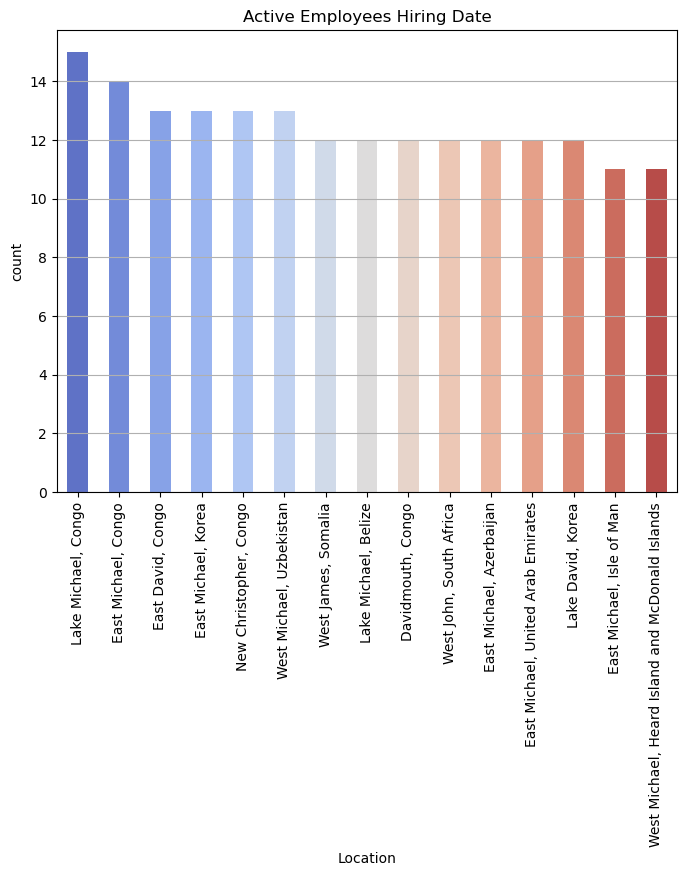

In [215]:
location = df[df.Status == "Active"]["Location"].value_counts().reset_index()
location = location.head(15)

plt.figure(figsize=(8,6))
ax = sns.barplot(location, x="Location", y="count", palette="coolwarm", width=0.5)

plt.title("Active Employees Hiring Date")
plt.xticks(rotation = 90)

plt.grid(axis="y")
plt.show()

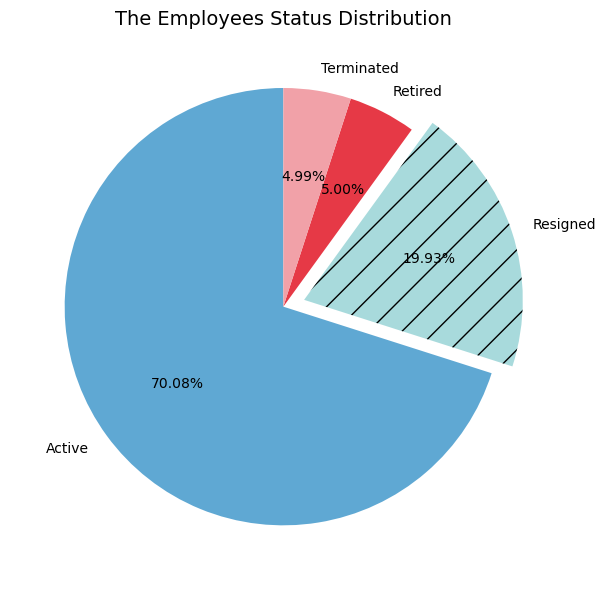

In [216]:
status = df["Status"].value_counts().reset_index() 
status

plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(
    status["count"],
    autopct="%1.2f%%",
    labels=status["Status"],
    colors=["#5FA8D3", "#A8DADC", "#E63946", "#F1A1A8"],
    explode=[0, 0.1, 0, 0],
    startangle=90
)

wedges[1].set_hatch("/")

plt.title("The Employees Status Distribution", fontsize=14)
plt.tight_layout()
plt.show()

In [217]:
df.head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_rating,Hire_Year
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363,Normal,2011
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686,Normal,2018
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084,Normal,2023
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,Normal,2023
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082,Normal,2024


In [218]:
df[df.Status == "Resigned"]["Performance_Rating"].mean()

2.9974815632368434

In [219]:
df[df.Status == "Resigned"]["Experience_Years"].value_counts()

Experience_Years
0     39954
3     39913
2     39899
4     39749
1     39513
5     32177
6     31992
7     31801
8     31758
9     31706
10     8331
11     7996
14     7952
13     7912
12     7902
15      105
Name: count, dtype: int64

In [220]:
df[df.Status == "Resigned"]["Work_Mode"].value_counts()

Work_Mode
On-site    238915
Remote     159745
Name: count, dtype: int64

In [221]:
df[df.Status == "Resigned"]["Salary_INR"].mean()

897755.5662143179

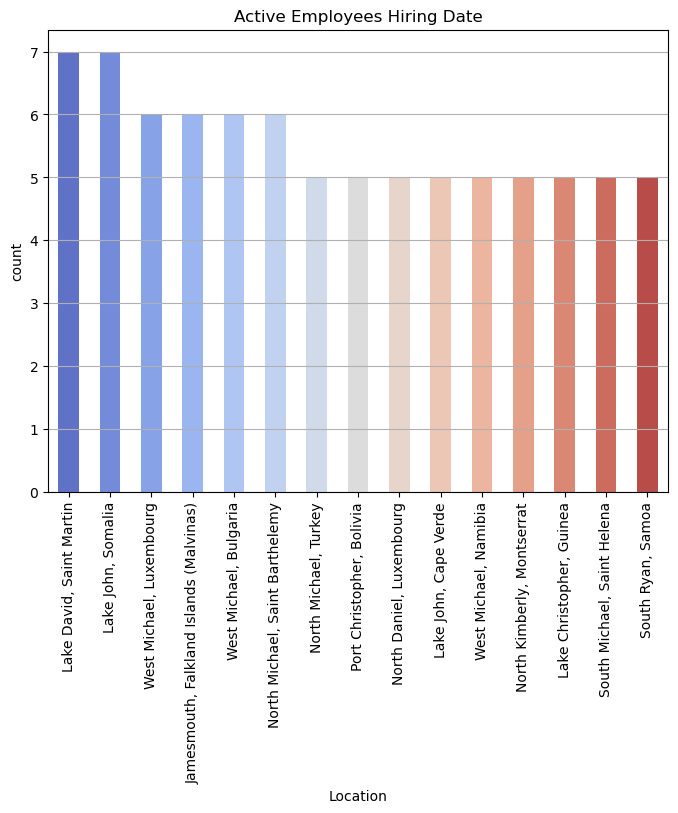

In [222]:
location = df[df.Status == "Resigned"]["Location"].value_counts().reset_index()
location = location.head(15)

plt.figure(figsize=(8,6))
ax = sns.barplot(location, x="Location", y="count", palette="coolwarm", width=0.5)

plt.title("Active Employees Hiring Date")
plt.xticks(rotation = 90)

plt.grid(axis="y")
plt.show()

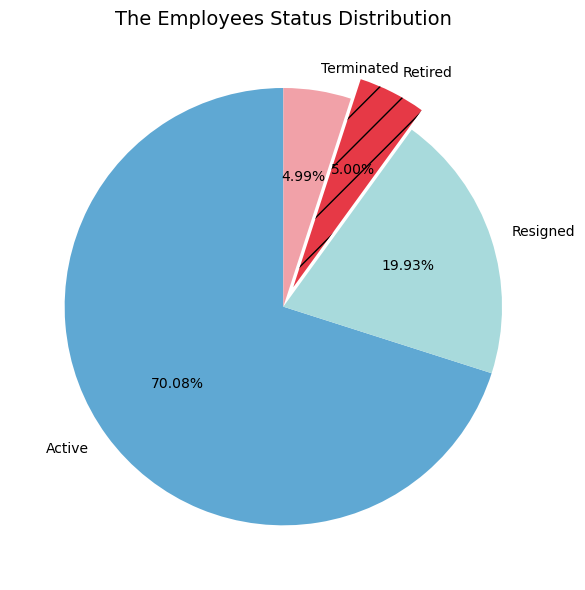

In [223]:
status = df["Status"].value_counts().reset_index() 
status

plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(
    status["count"],
    autopct="%1.2f%%",
    labels=status["Status"],
    colors=["#5FA8D3", "#A8DADC", "#E63946", "#F1A1A8"],
    explode=[0, 0, 0.1, 0],
    startangle=90
)

wedges[2].set_hatch("/")

plt.title("The Employees Status Distribution", fontsize=14)

plt.tight_layout()
plt.show()

In [224]:
df[df.Status == "Retired"]["Experience_Years"].value_counts()

Experience_Years
3     10031
1      9999
4      9981
2      9969
0      9898
9      8127
7      8082
8      7959
6      7929
5      7893
13     2049
10     2023
14     2002
12     1984
11     1963
15       23
Name: count, dtype: int64

In [225]:
df[df.Status == "Retired"]["Salary_INR"].mean()

894722.0102690367

In [226]:
df[df.Status == "Retired"]["Performance_Rating"].mean()

2.9922732004163666

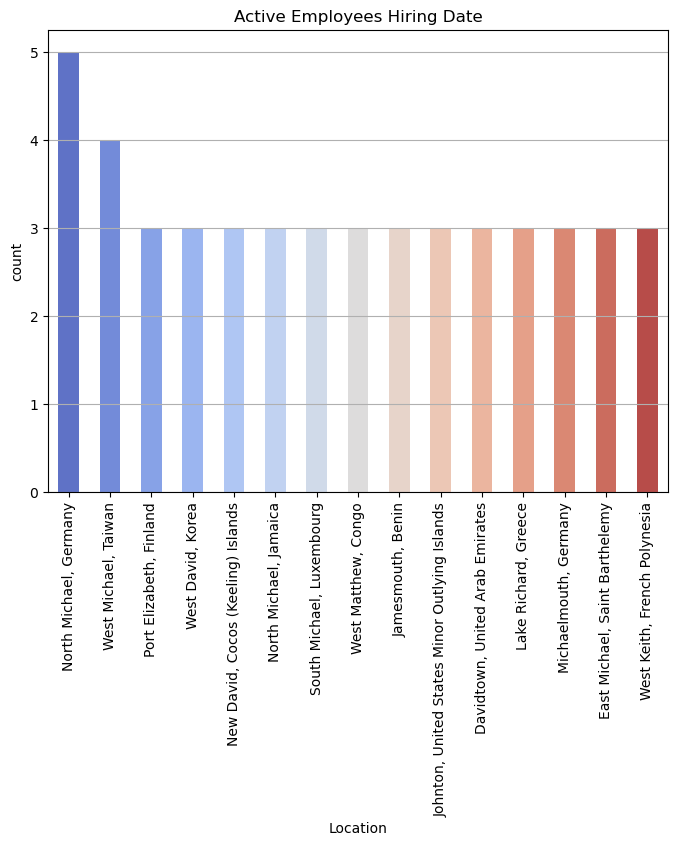

In [227]:
location = df[df.Status == "Retired"]["Location"].value_counts().reset_index()
location = location.head(15)

plt.figure(figsize=(8,6))
ax = sns.barplot(location, x="Location", y="count", palette="coolwarm", width=0.5)

plt.title("Active Employees Hiring Date")
plt.xticks(rotation = 90)

plt.grid(axis="y")
plt.show()


In [228]:
df[df.Status == "Terminated"]["Experience_Years"].value_counts()

Experience_Years
3     10263
2      9987
0      9959
1      9955
4      9935
9      8190
8      8031
6      7940
7      7841
5      7776
10     2070
11     2001
12     1987
13     1970
14     1938
15       27
Name: count, dtype: int64

In [229]:
df[df.Status == "Terminated"]["Work_Mode"].value_counts()

Work_Mode
On-site    59874
Remote     39996
Name: count, dtype: int64

In [230]:
df[df.Status == "Terminated"]["Salary_INR"].mean()

895513.1531390809

In [231]:
df[df.Status == "Terminated"]["Performance_Rating"].mean()

3.0027435666366276

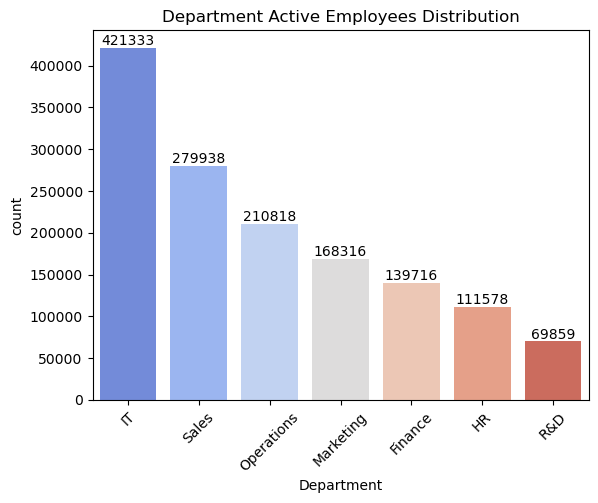

In [232]:
active = df[df.Status == "Active"]["Department"].value_counts().reset_index()
active

ax = sns.barplot(active, x="Department", y="count", palette="coolwarm")
for i in ax.containers: 
    ax.bar_label(i)

plt.xticks(rotation = 45)
plt.title("Department Active Employees Distribution")

plt.show()

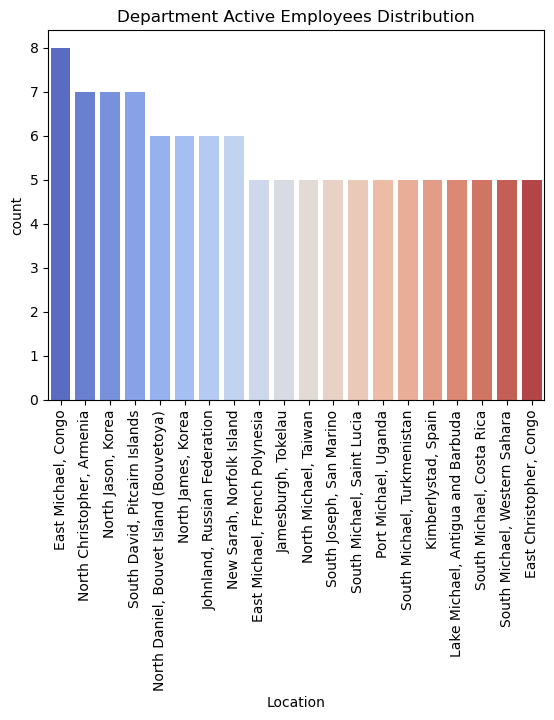

In [233]:
location_active = df[df.Status == "Active"][df.Department == "IT"]["Location"].value_counts().reset_index()
location_active = location_active.head(20)
location_active

sns.barplot(location_active, x="Location", y="count", palette="coolwarm")

plt.xticks(rotation = 90)
plt.title("Department Active Employees Distribution")

plt.show()

In [234]:
df[df.Status == "Active"][df.Department == "IT"]["Salary_INR"].mean()

1129490.712716545

<function matplotlib.pyplot.show(close=None, block=None)>

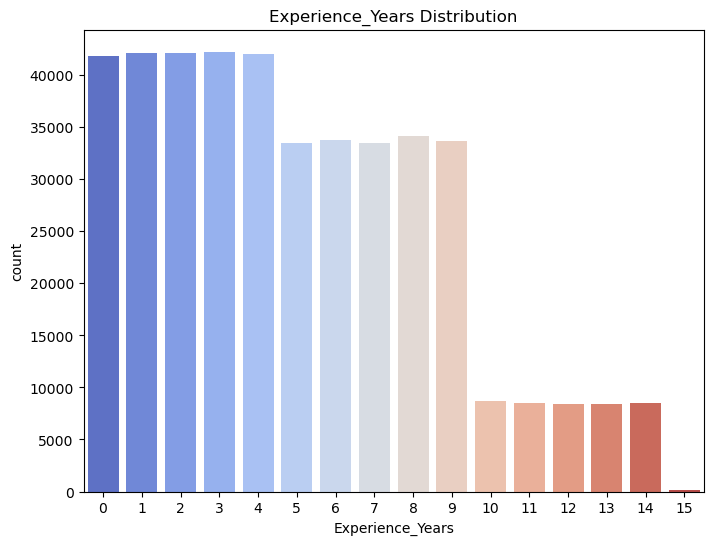

In [235]:
x = df[df.Status == "Active"][df.Department == "IT"]["Experience_Years"].value_counts().reset_index()
x

plt.figure(figsize=(8,6))
sns.barplot(x, x="Experience_Years", y="count", palette="coolwarm")

plt.title("Experience_Years Distribution")

plt.show

In [236]:
df[df.Status == "Active"][df.Department == "IT"].head()

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_rating,Hire_Year
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,Normal,2023
9,EMP0000010,Maria Yu MD,IT,Software Engineer,2015-10-08,"Brownport, Yemen",4,9,Active,Remote,1543102,Normal,2015
18,EMP0000019,Samuel Ferguson,IT,DevOps Engineer,2025-04-05,"Matthewsville, Ghana",2,0,Active,On-site,631273,Normal,2025
21,EMP0000022,Kylie May,IT,DevOps Engineer,2015-07-07,"Houstonland, Qatar",2,10,Active,On-site,723820,Normal,2015
24,EMP0000025,Amanda Miller,IT,IT Manager,2021-07-31,"Tammyview, Barbados",2,4,Active,Remote,2153098,High,2021


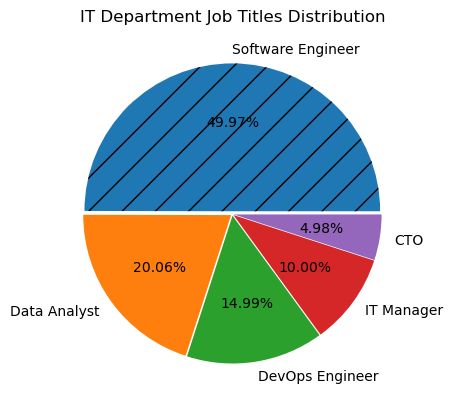

In [237]:
IT_job_title = df[df.Status == "Active"][df.Department == "IT"]["Job_Title"].value_counts().reset_index()
IT_job_title

wedges, texts, autotexts = plt.pie(IT_job_title["count"],
                                    labels=IT_job_title["Job_Title"],
                                    autopct="%1.2f%%", 
                                    explode = [0.02,0.01,0.01,0.01,0.01])
wedges[0].set_hatch("/")

plt.title("IT Department Job Titles Distribution")

plt.show()

In [238]:
df[df.Status == "Active"][df.Department == "IT"][df.Job_Title == "Software Engineer"]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_rating,Hire_Year
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689,Normal,2023
9,EMP0000010,Maria Yu MD,IT,Software Engineer,2015-10-08,"Brownport, Yemen",4,9,Active,Remote,1543102,Normal,2015
30,EMP0000031,Nathan Smith,IT,Software Engineer,2019-02-13,"Anthonyburgh, Bahamas",4,6,Active,On-site,1076433,Normal,2019
38,EMP0000039,Jeffrey Lucas,IT,Software Engineer,2021-10-20,"Thompsonport, Paraguay",1,3,Active,On-site,1054801,Normal,2021
41,EMP0000042,Justin Hendricks,IT,Software Engineer,2015-12-31,"Laurafort, Bahrain",1,9,Active,On-site,746812,Normal,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999948,EMP1999949,Mindy Boyer,IT,Software Engineer,2018-05-30,"East Keith, Albania",5,7,Active,On-site,1232011,Normal,2018
1999951,EMP1999952,Christina Davis,IT,Software Engineer,2021-09-26,"Port Dustin, Kenya",5,3,Active,On-site,1305047,Normal,2021
1999975,EMP1999976,Dorothy Patterson,IT,Software Engineer,2017-12-27,"Peterberg, Denmark",4,7,Active,On-site,1089510,Normal,2017
1999980,EMP1999981,Mackenzie Juarez,IT,Software Engineer,2022-01-23,"East Gary, Fiji",3,3,Active,On-site,1363789,Normal,2022


In [239]:
df[df.Status == "Active"][df.Department == "IT"][df.Job_Title == "Software Engineer"]["Salary_INR"].mean()

1199077.4773263794

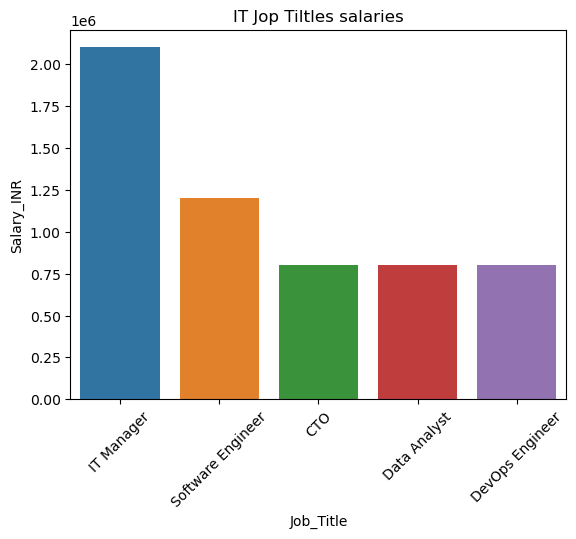

In [240]:
IT_salary = df.loc[df.Department == "IT"].groupby("Job_Title")["Salary_INR"].mean().sort_values(ascending= False).reset_index()
IT_salary

sns.barplot(IT_salary, x = "Job_Title", y="Salary_INR")

plt.title("IT Jop Tiltles salaries")
plt.xticks(rotation = 45)

plt.show()

In [241]:
sum = 0
for i in df.Location.unique():
    sum += 1 
sum

1593497

In [242]:
df.Location.value_counts()

Location
Lake Michael, Congo                                                   20
New Christopher, Congo                                                19
East Michael, Congo                                                   17
West Michael, Sao Tome and Principe                                   16
South Michael, British Indian Ocean Territory (Chagos Archipelago)    16
                                                                      ..
West Robertshire, Gibraltar                                            1
Port Alexahaven, Jersey                                                1
Luceroton, Syrian Arab Republic                                        1
North Amandaberg, Cook Islands                                         1
Morganchester, Canada                                                  1
Name: count, Length: 1593497, dtype: int64

In [243]:
df[df.Location == "Lake Michael, Congo"]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_rating,Hire_Year
5919,EMP0005920,Emily Yang,Marketing,Marketing Executive,2025-07-14,"Lake Michael, Congo",2,0,Active,On-site,504649,Normal,2025
30336,EMP0030337,Amanda Walker,Sales,Business Development Manager,2019-03-08,"Lake Michael, Congo",5,6,Active,On-site,1356176,Normal,2019
442001,EMP0442002,Jennifer Wolfe,IT,Software Engineer,2023-08-15,"Lake Michael, Congo",2,2,Resigned,On-site,789330,Normal,2023
477641,EMP0477642,Glenda Gonzalez,IT,Software Engineer,2017-10-31,"Lake Michael, Congo",5,7,Active,On-site,1310254,Normal,2017
532050,EMP0532051,Tammy Bryan,Marketing,SEO Specialist,2017-10-15,"Lake Michael, Congo",4,7,Resigned,On-site,689676,Normal,2017
606142,EMP0606143,Sabrina Dixon,Operations,Logistics Coordinator,2023-12-06,"Lake Michael, Congo",4,1,Active,Remote,596380,Normal,2023
841194,EMP0841195,Brandon Castillo,IT,DevOps Engineer,2012-08-31,"Lake Michael, Congo",5,12,Resigned,Remote,1150633,Normal,2012
968788,EMP0968789,Donald Ward,Finance,Accountant,2017-05-23,"Lake Michael, Congo",4,8,Active,Remote,652374,Normal,2017
1172470,EMP1172471,Mark Collins,Sales,Sales Executive,2015-03-14,"Lake Michael, Congo",4,10,Active,On-site,661773,Normal,2015
1230786,EMP1230787,Gerald Howard,Marketing,Marketing Executive,2013-03-13,"Lake Michael, Congo",5,12,Active,Remote,911098,Normal,2013


In [244]:
df.Performance_Rating.value_counts()

Performance_Rating
4    400529
2    400174
3    399814
1    399756
5    399727
Name: count, dtype: int64

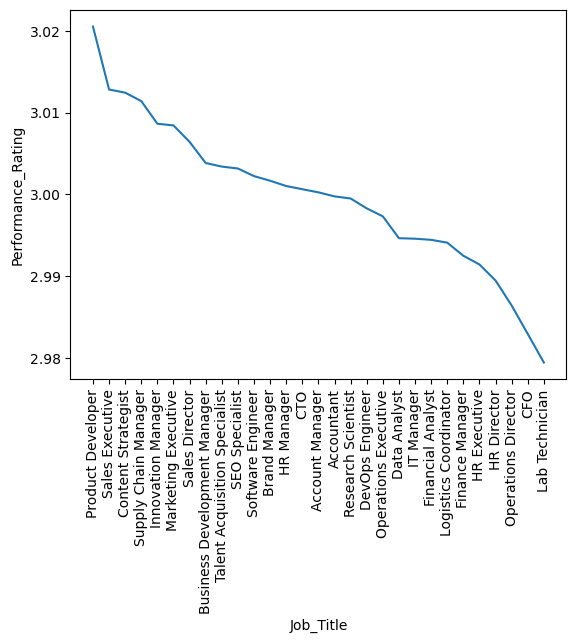

In [245]:
Performance_Rating = df.loc[df.Status == "Active"].groupby("Job_Title")["Performance_Rating"].mean().reset_index().sort_values(by="Performance_Rating",ascending =False )
Performance_Rating

sns.lineplot(Performance_Rating, x="Job_Title", y="Performance_Rating")
plt.xticks(rotation = 90)

plt.show()

In [246]:
df.loc[df.Status == "Active"][df.Performance_Rating == 5]["Salary_INR"].mean()

896654.2735438652

In [247]:
df.loc[df.Status == "Active"][df.Performance_Rating == 1]["Salary_INR"].mean()

897294.0128636326

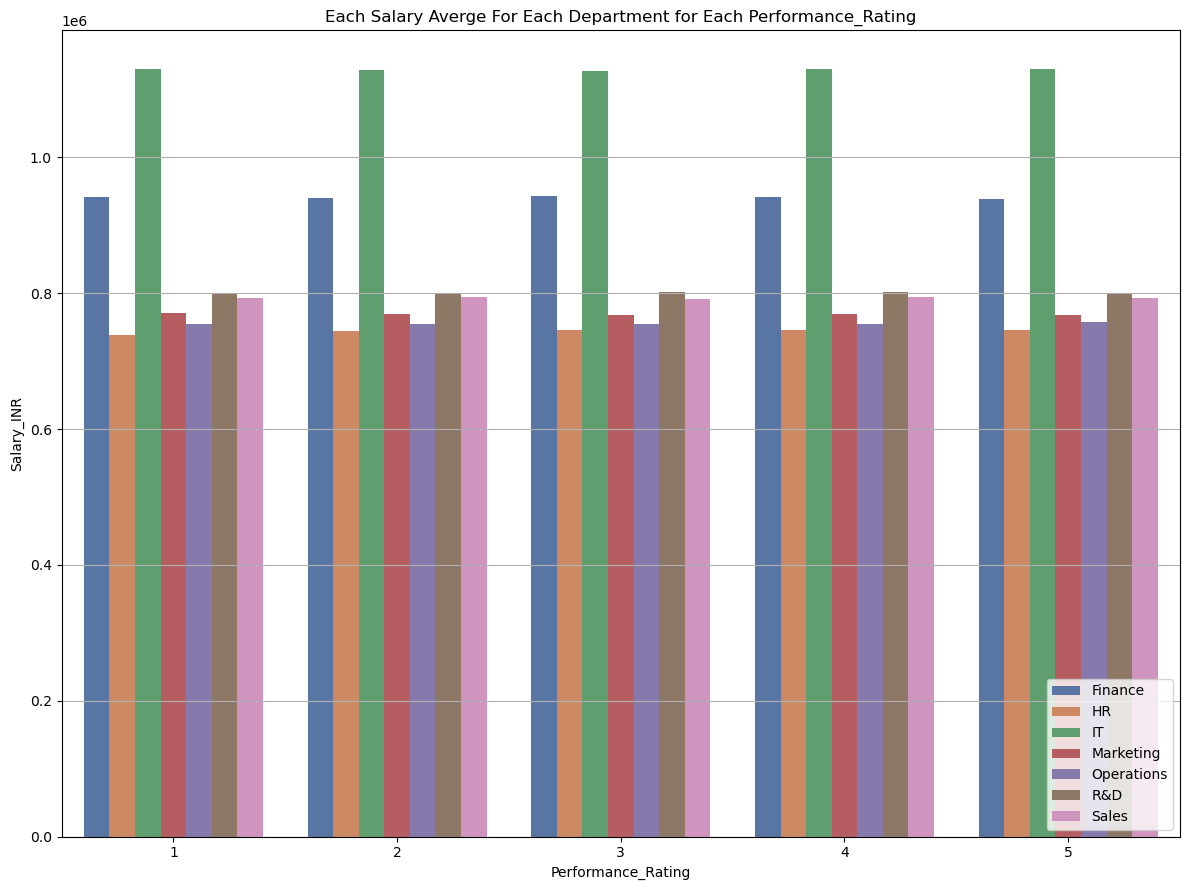

In [248]:
x= df.loc[df.Status == "Active"].groupby(["Department", "Performance_Rating"])["Salary_INR"].mean().reset_index()
x

plt.figure(figsize=(12,9))
sns.barplot(x, x="Performance_Rating", y= "Salary_INR", hue="Department", palette="deep")

plt.title("Each Salary Averge For Each Department for Each Performance_Rating")

plt.tight_layout()
plt.legend(loc = "lower right")
plt.grid(axis= "y")
plt.show()

In [249]:
df.Experience_Years.value_counts()

Experience_Years
3     200522
2     199924
4     199866
1     199162
0     198775
6     160410
9     160223
8     160212
5     160112
7     159005
10     41209
13     40149
11     40146
14     40005
12     39709
15       571
Name: count, dtype: int64

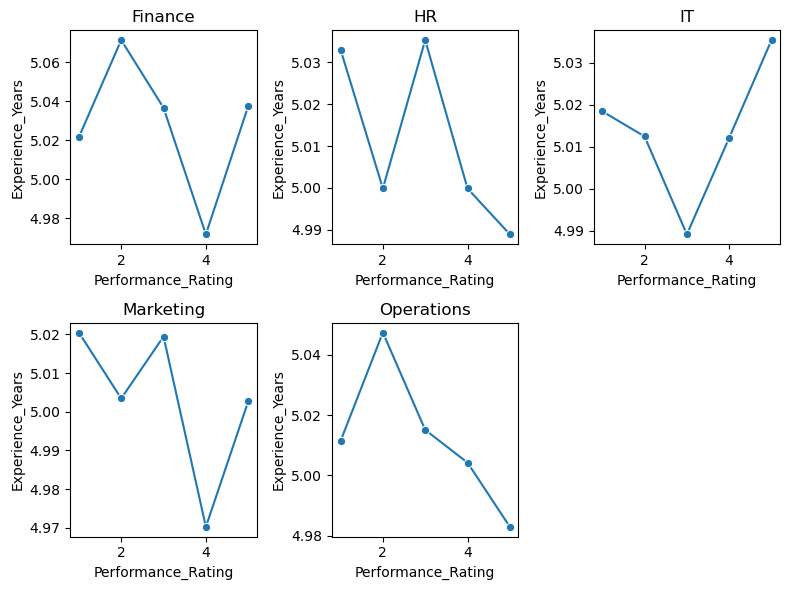

In [250]:
x = df.loc[df.Status == "Active"].groupby(["Department", "Performance_Rating"])["Experience_Years"].mean().reset_index()

fig, axs = plt.subplots(2, 3, figsize=(8,6))
axs = axs.flatten()

for i, dept in enumerate(x["Department"].unique()[:5]):
    sns.lineplot(
        data=x[x["Department"] == dept],
        x="Performance_Rating",
        y="Experience_Years",
        ax=axs[i],
        marker="o"
    )
    axs[i].set_title(dept)

axs[-1].axis("off")

plt.tight_layout()
plt.show()

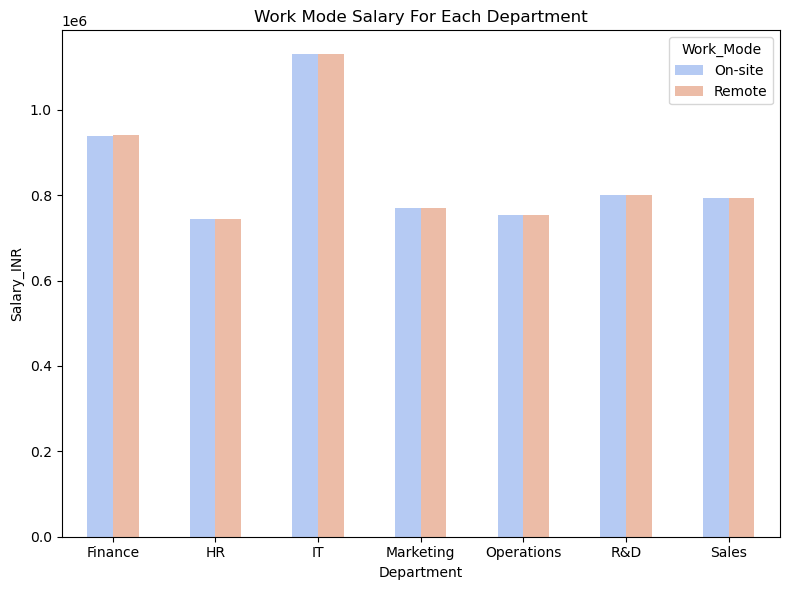

In [251]:
x = df.groupby(["Work_Mode", "Department"])["Salary_INR"].mean().reset_index()
x


plt.figure(figsize=(8,6))
sns.barplot(x, x="Department", y = "Salary_INR", hue="Work_Mode", palette="coolwarm", width= 0.5)

plt.title("Work Mode Salary For Each Department")

plt.tight_layout()
plt.show()